# Parks Meteo Optimization Analysis

This notebook demonstrates the end-to-end pipeline for meteorological data analysis in parks, including ingestion, cleaning, redundancy analysis, FWI computation, and uncertainty modeling.

## Notebook Outline
1. **Data Audit**: Review data quality, missing values, and initial statistics.
2. **PCA & Clustering**: Perform principal component analysis and K-means clustering for redundancy detection.
3. **FWI Validation**: Compute and validate Fire Weather Index against expected ranges.
4. **KDE Uncertainty Modeling**: Estimate uncertainty in data processing using kernel density estimation.
5. **Final Insights and Recommendations**: Summarize findings and suggest optimizations for park microclimate monitoring.

## Import Required Libraries

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path
from IPython.display import Image, display

# Import agents
from src.agents.ingest_agent import IngestAgent
from src.agents.clean_agent import CleanAgent
from src.agents.redundancy_agent import RedundancyAgent
from src.agents.fwi_agent import FWIAgent
from src.agents.uncertainty_agent import UncertaintyAgent

# Setup logging so agent messages appear
logging.basicConfig(level=logging.INFO, format="%(name)s - %(levelname)s - %(message)s")

# Set plot style
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100

## Load Data

In [2]:
# Instantiate IngestAgent
ingest_agent = IngestAgent(data_dir='data/raw', output_dir='data/processed')

# Load and process data (daily resampling)
ingested_df = ingest_agent.ingest(resample='D')

print(f"Ingested data shape: {ingested_df.shape}")
print(f"Columns: {list(ingested_df.columns)}")
ingested_df.head()

IngestAgent - INFO - Normalized columns: ['gust_speed_ms', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'wind_speed_ms']
IngestAgent - INFO - Normalized columns: ['gust_speed_ms', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'wind_speed_ms']
IngestAgent - INFO - Normalized columns: ['gust_speed_ms', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'wind_speed_ms']
IngestAgent - INFO - Normalized columns: ['gust_speed_ms', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'w

Ingested data shape: (5086, 20)
Columns: ['station', 'timestamp', 'gust_speed_ms', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'wind_speed_ms', 'accumulated_rain', 'water_flow', 'humidity', 'dew_point']


,station,timestamp,gust_speed_ms,solar_radiation,rain,temperature,battery,wind_direction,barometric_pressure,water_pressure,diff_pressure,water_temperature,water_level,wind,gust_speed,wind_speed_ms,accumulated_rain,water_flow,humidity,dew_point
0,Cavendish,2022-10-12 00:00:00+00:00,NaN,274.073171,0.0,14.533252,4.296390,244.154472,NaN,NaN,NaN,NaN,NaN,9.609756,16.008130,NaN,NaN,NaN,56.101626,5.691463
1,Cavendish,2022-10-13 00:00:00+00:00,NaN,118.173611,0.0,14.532639,4.262646,204.934028,NaN,NaN,NaN,NaN,NaN,8.656250,14.368056,NaN,NaN,NaN,69.769444,8.591354
2,Cavendish,2022-10-14 00:00:00+00:00,NaN,83.565972,0.0,14.528160,4.267628,163.166667,NaN,NaN,NaN,NaN,NaN,15.052083,23.170139,NaN,NaN,NaN,80.934375,11.128021
3,Cavendish,2022-10-15 00:00:00+00:00,NaN,47.982639,0.0,15.379410,4.266851,153.472222,NaN,NaN,NaN,NaN,NaN,18.020833,28.489583,NaN,NaN,NaN,87.826389,13.367222
4,Cavendish,2022-10-16 00:00:00+00:00,NaN,77.645833,0.0,15.905764,4.268059,150.628472,NaN,NaN,NaN,NaN,NaN,12.413194,20.340278,NaN,NaN,NaN,89.152431,14.106563


## Data Cleaning and Preprocessing

In [3]:
# Instantiate CleanAgent
clean_agent = CleanAgent(output_dir='data/cleaned')

# Run cleaning — returns the cleaned DataFrame directly
cleaned_df = clean_agent.run(ingested_df, filename='cleaned_data.parquet')

print(f"Cleaned data shape: {cleaned_df.shape}")
print(f"Columns kept: {list(cleaned_df.columns)}")
cleaned_df.head()

CleanAgent - INFO - Starting cleaning pipeline...
CleanAgent - INFO - Missing values per column (non-zero only):
CleanAgent - INFO - gust_speed_ms          5084
solar_radiation         229
rain                    239
temperature             616
battery                 135
wind_direction          549
barometric_pressure    2625
water_pressure         2625
diff_pressure          2625
water_temperature      2625
water_level            2948
wind                    934
gust_speed              934
wind_speed_ms          5084
accumulated_rain       4112
water_flow             5086
humidity               2224
dew_point              2255
dtype: int64
CleanAgent - INFO - Range issues in temperature: 2 rows
CleanAgent - INFO - Cleaned DataFrame shape: (5086, 16) (from original (5086, 20))
CleanAgent - INFO - Cleaned data saved to data/cleaned\cleaned_data.parquet


Cleaned data shape: (5086, 16)
Columns kept: ['station', 'timestamp', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'humidity', 'dew_point']


,station,timestamp,solar_radiation,rain,temperature,battery,wind_direction,barometric_pressure,water_pressure,diff_pressure,water_temperature,water_level,wind,gust_speed,humidity,dew_point
0,Cavendish,2022-10-12 00:00:00+00:00,274.073171,0.0,14.533252,4.296390,244.154472,101.500591,107.605583,6.104959,9.987487,0.223424,9.609756,16.008130,56.101626,5.691463
1,Cavendish,2022-10-13 00:00:00+00:00,118.173611,0.0,14.532639,4.262646,204.934028,101.500591,107.605583,6.104959,9.987487,0.223424,8.656250,14.368056,69.769444,8.591354
2,Cavendish,2022-10-14 00:00:00+00:00,83.565972,0.0,14.528160,4.267628,163.166667,101.500591,107.605583,6.104959,9.987487,0.223424,15.052083,23.170139,80.934375,11.128021
3,Cavendish,2022-10-15 00:00:00+00:00,47.982639,0.0,15.379410,4.266851,153.472222,101.500591,107.605583,6.104959,9.987487,0.223424,18.020833,28.489583,87.826389,13.367222
4,Cavendish,2022-10-16 00:00:00+00:00,77.645833,0.0,15.905764,4.268059,150.628472,101.500591,107.605583,6.104959,9.987487,0.223424,12.413194,20.340278,89.152431,14.106563


## Redundancy Analysis

RedundancyAgent - INFO - Starting redundancy analysis...
RedundancyAgent - INFO - Merged DataFrame shape: (5086, 16)
RedundancyAgent - INFO - Standardized 14 numeric columns.
RedundancyAgent - INFO - PCA completed. Variance explained: [0.23055175 0.15262811 0.14568928]
RedundancyAgent - INFO - Clustering completed.
RedundancyAgent - INFO - Correlation heatmap saved to outputs/redundancy\correlation_heatmap.png


PCA explained variance: [0.23055175 0.15262811 0.14568928]
Cluster distribution:
2    2413
1    2322
0     351
Name: count, dtype: int64


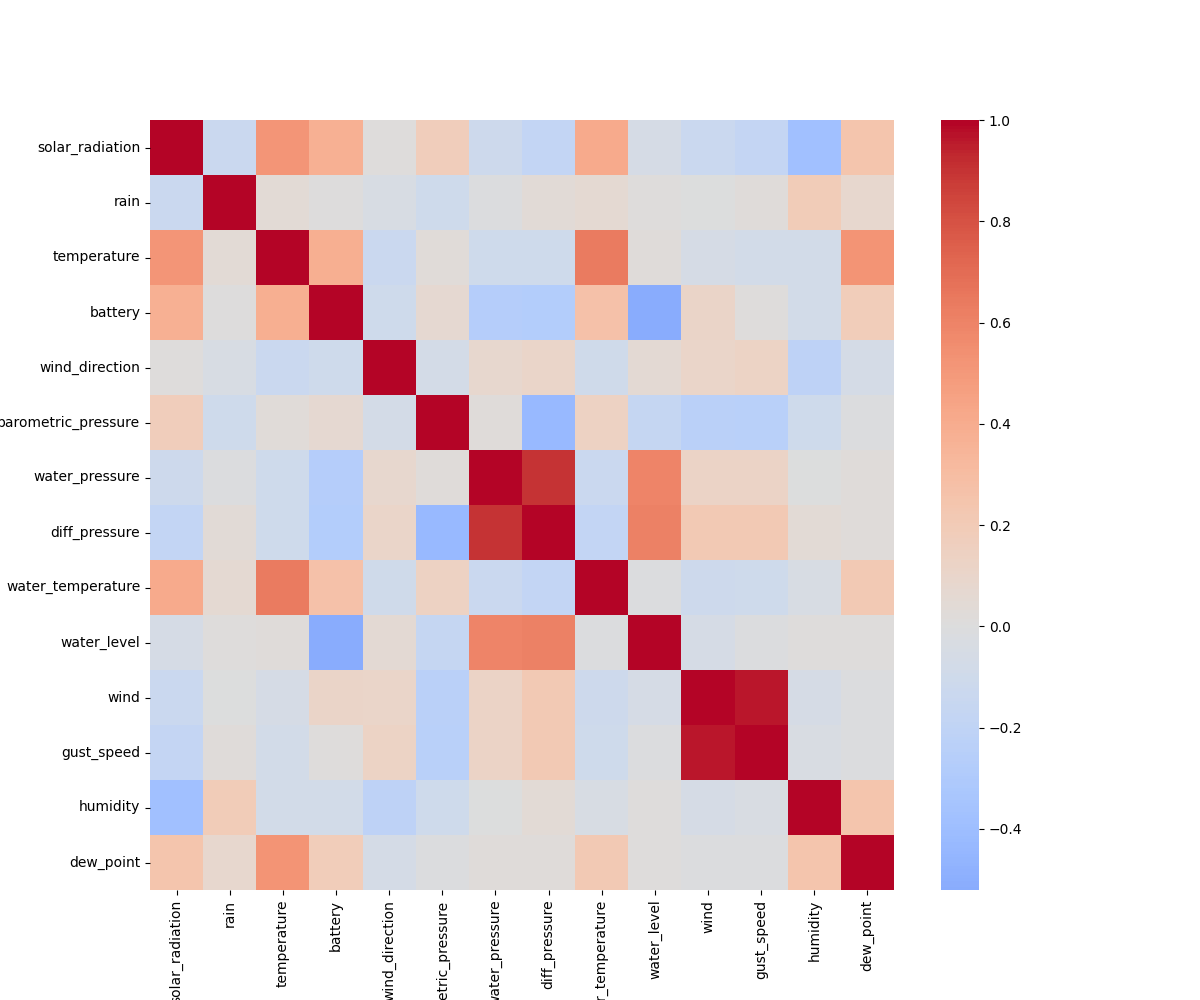

In [4]:
# Instantiate RedundancyAgent
redundancy_agent = RedundancyAgent(output_dir='outputs/redundancy')

# Run analysis — pass a single DataFrame (not a list)
redundancy_result = redundancy_agent.run_analysis(cleaned_df, merge_on='timestamp')

# PCA results
if redundancy_result['pca'] is not None:
    print(f"PCA explained variance: {redundancy_result['pca']['explained_variance']}")

# Cluster labels
if redundancy_result['clusters'] is not None:
    cluster_counts = pd.Series(redundancy_result['clusters']).value_counts()
    print(f"Cluster distribution:\n{cluster_counts}")

# Display correlation heatmap
if redundancy_result['correlation_heatmap'] is not None:
    display(Image(redundancy_result['correlation_heatmap']))

## FWI Computation

FWIAgent - INFO - Starting FWI computation
FWIAgent - INFO - Computing FWI per station: ['Cavendish', 'Greenwich', 'North Rustico Wharf', 'Stanley Bridge Wharf', 'Tracadie Wharf'] (5086 total time steps)
FWIAgent - INFO -   Cavendish: 1117 days, peak FWI 32.7
FWIAgent - INFO -   Greenwich: 1165 days, peak FWI 26.3
FWIAgent - INFO -   North Rustico Wharf: 994 days, peak FWI 37.7
FWIAgent - INFO -   Stanley Bridge Wharf: 892 days, peak FWI 55.8
FWIAgent - INFO -   Tracadie Wharf: 918 days, peak FWI 47.9
FWIAgent - INFO - FWI computation complete. Shape: (5086, 11)
FWIAgent - INFO - Saved FWI results to outputs\fwi\fwi_results.csv
FWIAgent - INFO - Saved FWI plot to outputs\fwi\fwi_plot.png


FWI data shape: (5086, 11)


,temperature,humidity,wind,rain,ffmc,dmc,dc,isi,bui,fwi
timestamp,,,,,,,,,,
2022-10-12 00:00:00+00:00,14.533252,56.101626,9.609756,0.0,85.326341,7.039843,18.319985,3.577481,7.181029,3.116964
2022-10-13 00:00:00+00:00,14.532639,69.769444,8.656250,0.0,84.828009,7.755901,21.639860,3.183501,8.181243,2.923339
2022-10-14 00:00:00+00:00,14.528160,80.934375,15.052083,0.0,82.790226,8.207371,24.958929,3.356590,9.008755,3.317666
2022-10-15 00:00:00+00:00,15.379410,87.826389,18.020833,0.0,80.703945,8.511341,28.431223,3.041006,9.736065,3.094090
2022-10-16 00:00:00+00:00,15.905764,89.152431,12.413194,0.0,79.976074,8.790852,31.998260,2.120304,10.422971,1.968375


FWIAgent - INFO - Validating FWI against expected ranges
FWIAgent - INFO - FFMC OK — min=67.62, max=97.71, mean=80.41
FWIAgent - INFO - DMC OK — min=6.65, max=517.54, mean=210.07
FWIAgent - INFO - DC OK — min=17.12, max=3266.09, mean=1469.07
FWIAgent - INFO - ISI OK — min=0.75, max=16.99, mean=2.46
FWIAgent - INFO - BUI OK — min=7.00, max=741.38, mean=309.18
FWIAgent - INFO - FWI OK — min=0.68, max=55.79, mean=13.06
FWIAgent - INFO - Range validation PASSED



--- FWI Range Validation ---
   FFMC: min=   67.62  max=   97.71  mean=   80.41  ✓
    DMC: min=    6.65  max=  517.54  mean=  210.07  ✓
     DC: min=   17.12  max= 3266.09  mean= 1469.07  ✓
    ISI: min=    0.75  max=   16.99  mean=    2.46  ✓
    BUI: min=    7.00  max=  741.38  mean=  309.18  ✓
    FWI: min=    0.68  max=   55.79  mean=   13.06  ✓

Overall: PASSED ✓


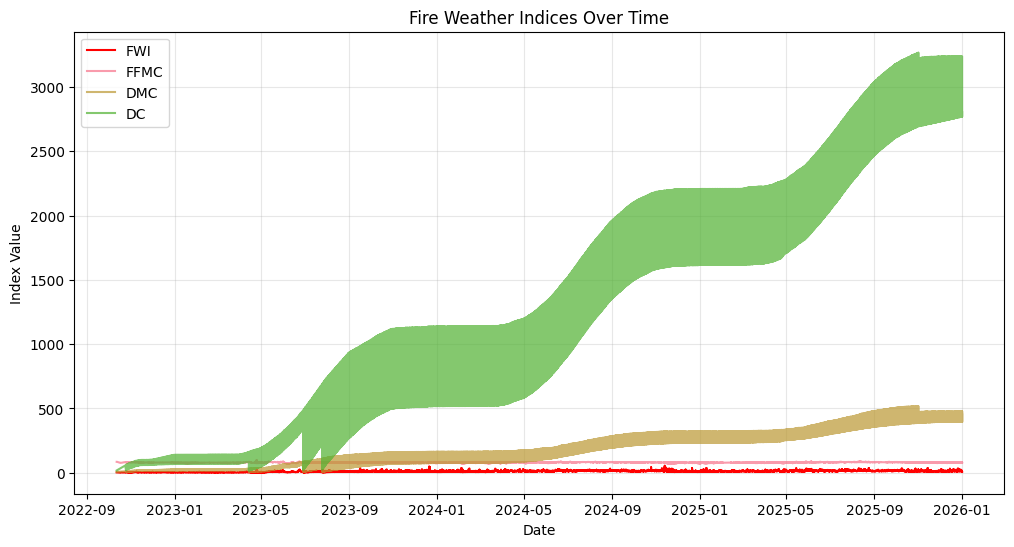

In [5]:
# Instantiate FWIAgent
fwi_agent = FWIAgent(output_dir='outputs/fwi')

# Compute FWI — returns (DataFrame, plot_path) tuple
fwi_df, fwi_plot_path = fwi_agent.compute_fwi(cleaned_df)

print(f"FWI data shape: {fwi_df.shape}")
display(fwi_df[['temperature', 'humidity', 'wind', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']].head())

# Validate FWI against expected physical ranges
validation_report = fwi_agent.validate_ranges(fwi_df)

print("\n--- FWI Range Validation ---")
for idx, stats in validation_report.items():
    if idx == 'all_passed':
        print(f"\nOverall: {'PASSED ✓' if stats else 'FAILED ✗'}")
    else:
        status = '✓' if stats['passed'] else f"✗ ({stats['violations']} violations)"
        print(f"  {idx.upper():>5s}: min={stats['min']:8.2f}  max={stats['max']:8.2f}  mean={stats['mean']:8.2f}  {status}")

# Display FWI plot
if fwi_plot_path is not None:
    display(Image(str(fwi_plot_path)))

## Uncertainty Modeling

### FWI Cross-Validation against Stanhope Reference

Compare our Van Wagner implementation against the independently computed Stanhope FWI (ECCC station 8300590). The reference was computed from noon observations via the ECCC API in `stanhope-fwi/`.

FWIAgent - INFO - Starting FWI computation
FWIAgent - INFO - Processing 368 time steps
FWIAgent - INFO - FWI computation complete. Shape: (368, 10)
FWIAgent - INFO - Saved FWI results to outputs\fwi\fwi_crossval.csv
FWIAgent - INFO - Starting FWI validation
FWIAgent - INFO - FFMC - MAE: 0.0248, Max Error: 5.8646
FWIAgent - INFO - DMC - MAE: 0.7000, Max Error: 23.3276
FWIAgent - INFO - DC - MAE: 53.2911, Max Error: 261.8506
FWIAgent - INFO - ISI - MAE: 0.0152, Max Error: 3.3617
FWIAgent - INFO - BUI - MAE: 3.2027, Max Error: 41.1168
FWIAgent - INFO - FWI - MAE: 0.3722, Max Error: 5.9757
FWIAgent - INFO - FWI validation complete


Loaded fwi_stanhope_computed_2020.csv: 184 rows, 2020-05-01 to 2020-10-31
Loaded fwi_stanhope_computed_2025.csv: 184 rows, 2025-05-01 to 2025-10-31

Combined reference: 368 rows
Date range: 2020-05-01 to 2025-10-31

FWI CROSS-VALIDATION vs STANHOPE REFERENCE
   FFMC      MAE: 0.0248
  FFMC_MAX  Max Err: 5.8646
    DMC      MAE: 0.7000
  DMC_MAX  Max Err: 23.3276
     DC      MAE: 53.2911
  DC_MAX  Max Err: 261.8506
    ISI      MAE: 0.0152
  ISI_MAX  Max Err: 3.3617
    BUI      MAE: 3.2027
  BUI_MAX  Max Err: 41.1168
    FWI      MAE: 0.3722
  FWI_MAX  Max Err: 5.9757


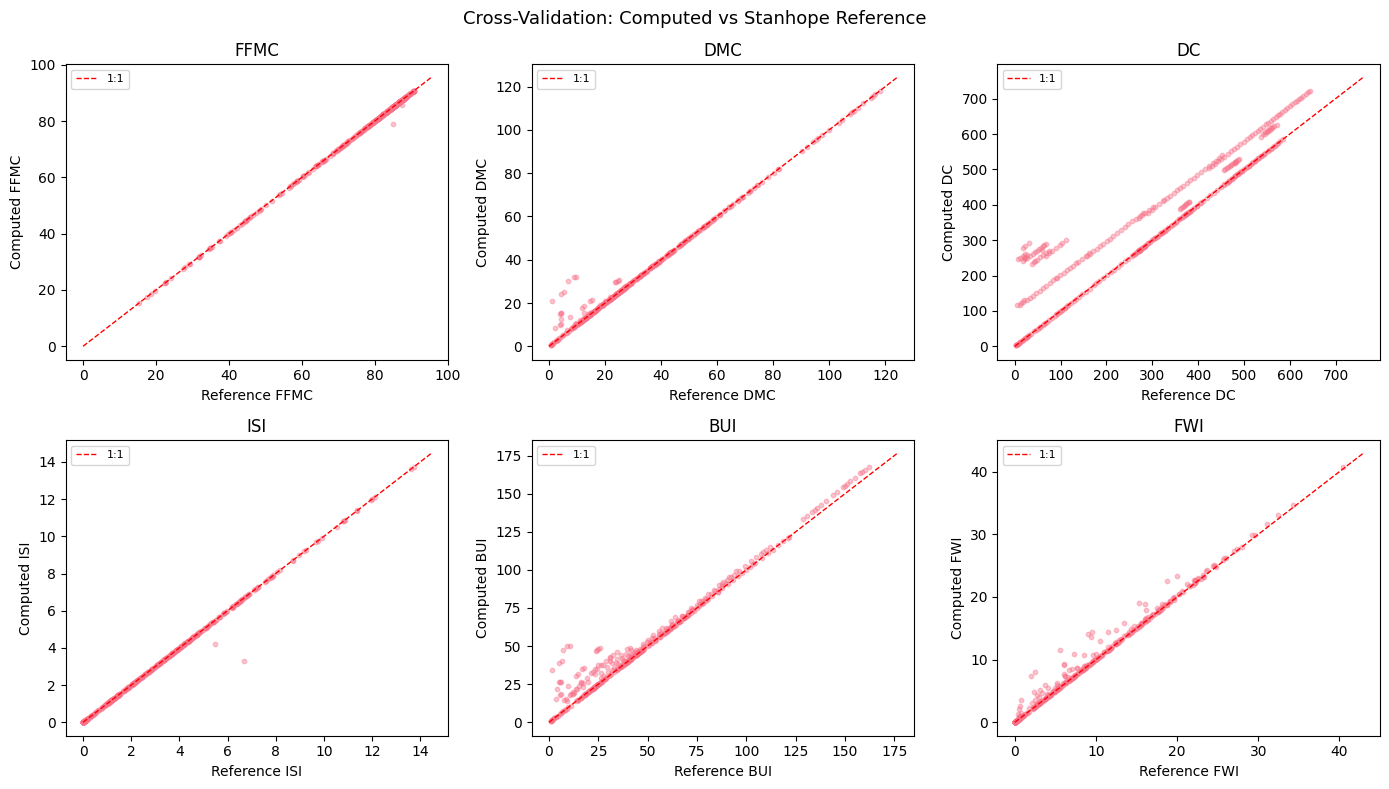

In [9]:
# Load Stanhope reference FWI data (2020 + 2025)
ref_frames = []
for fname in ['fwi_stanhope_computed_2020.csv', 'fwi_stanhope_computed_2025.csv']:
    fp = Path('stanhope-fwi/data/stanhope') / fname
    if fp.exists():
        tmp = pd.read_csv(fp, parse_dates=['Date'], index_col='Date')
        ref_frames.append(tmp)
        print(f"Loaded {fname}: {len(tmp)} rows, {tmp.index.min().date()} to {tmp.index.max().date()}")

ref_df = pd.concat(ref_frames).sort_index()
ref_df.columns = [c.lower() for c in ref_df.columns]

# Rename reference columns to match our schema
ref_df = ref_df.rename(columns={
    't_noon': 'temperature', 'rh_noon': 'humidity',
    'wind_noon': 'wind', 'precip_24h': 'rain',
})

print(f"\nCombined reference: {len(ref_df)} rows")
print(f"Date range: {ref_df.index.min().date()} to {ref_df.index.max().date()}")

# Compute FWI from the Stanhope reference weather inputs using our implementation
our_fwi, _ = fwi_agent.compute_fwi(
    ref_df[['temperature', 'humidity', 'wind', 'rain']],
    save_as='fwi_crossval.csv', plot=False
)

# Cross-validate against the reference FWI values
metrics = fwi_agent.validate(our_fwi, ref_df)

print("\n" + "=" * 60)
print("FWI CROSS-VALIDATION vs STANHOPE REFERENCE")
print("=" * 60)
for key, val in metrics.items():
    idx_name, metric = key.rsplit('_', 1)
    label = "MAE" if metric == "mae" else "Max Err"
    print(f"  {idx_name.upper():>5s} {label:>8s}: {val:.4f}")

# Quick scatter of our FWI vs reference FWI
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']):
    common = our_fwi.index.intersection(ref_df.index)
    ax.scatter(ref_df.loc[common, col], our_fwi.loc[common, col], alpha=0.4, s=10)
    lim = max(ref_df.loc[common, col].max(), our_fwi.loc[common, col].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1, label='1:1')
    ax.set_xlabel(f'Reference {col.upper()}')
    ax.set_ylabel(f'Computed {col.upper()}')
    ax.set_title(col.upper())
    ax.legend(fontsize=8)
plt.suptitle('Cross-Validation: Computed vs Stanhope Reference', fontsize=13)
plt.tight_layout()
plt.show()

UncertaintyAgent - INFO - Starting uncertainty analysis...
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_solar_radiation_original.png
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_solar_radiation_cleaned.png
UncertaintyAgent - INFO - solar_radiation prob_loss = 0.0331
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_rain_original.png
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_rain_cleaned.png
UncertaintyAgent - INFO - rain prob_loss = 0.0106
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_temperature_original.png
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_temperature_cleaned.png
UncertaintyAgent - INFO - temperature prob_loss = 0.0932
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_battery_original.png
UncertaintyAgent - INFO - KDE plot saved to outputs/uncertainty\kde_battery_cleaned.png
UncertaintyAgent - INFO - battery prob_loss = 0

--- Probability Loss (cleaning impact) ---
         solar_radiation: 0.0331  █
                    rain: 0.0106  
             temperature: 0.0932  ███
                 battery: 0.0151  
          wind_direction: 0.0738  ██
     barometric_pressure: 0.3826  ███████████████
          water_pressure: 0.3648  ██████████████
           diff_pressure: 0.3628  ██████████████
       water_temperature: 0.4200  ████████████████
             water_level: 0.4790  ███████████████████
                    wind: 0.1265  █████
              gust_speed: 0.1275  █████
                humidity: 0.3284  █████████████
               dew_point: 0.3165  ████████████


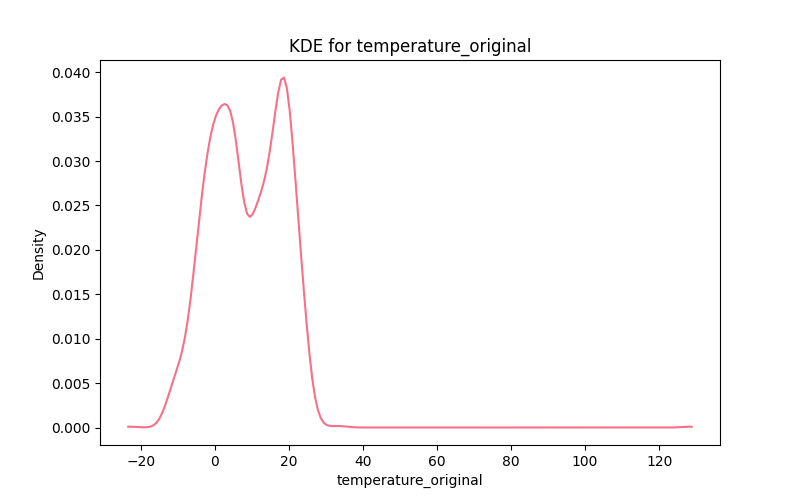

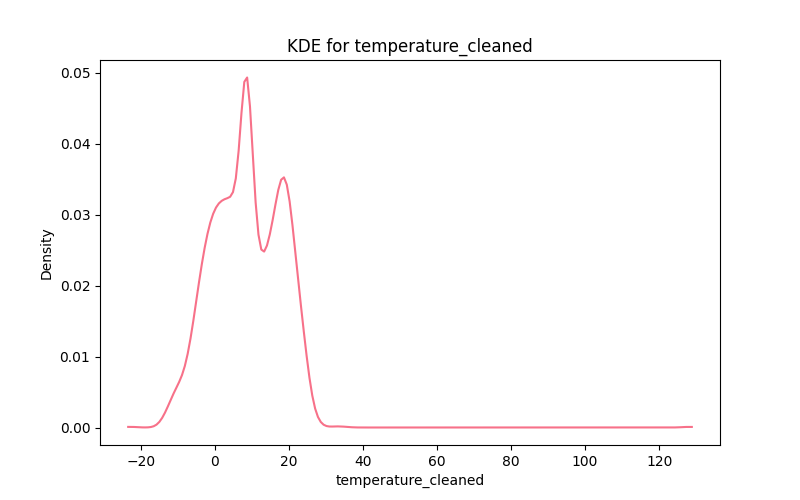

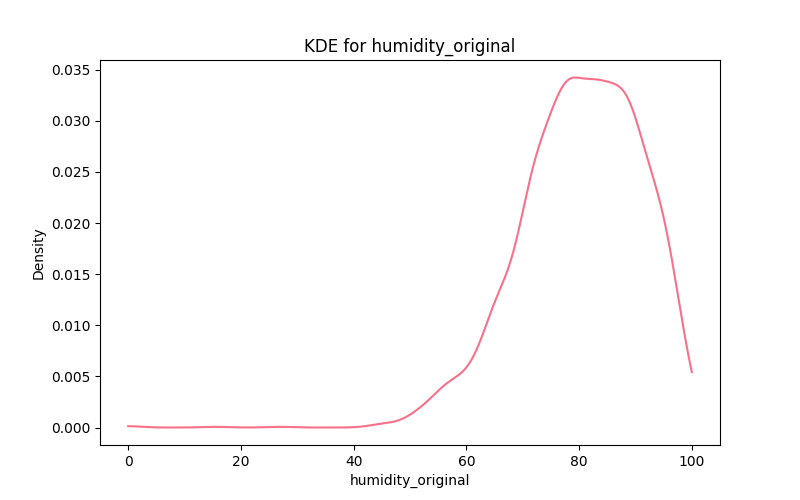

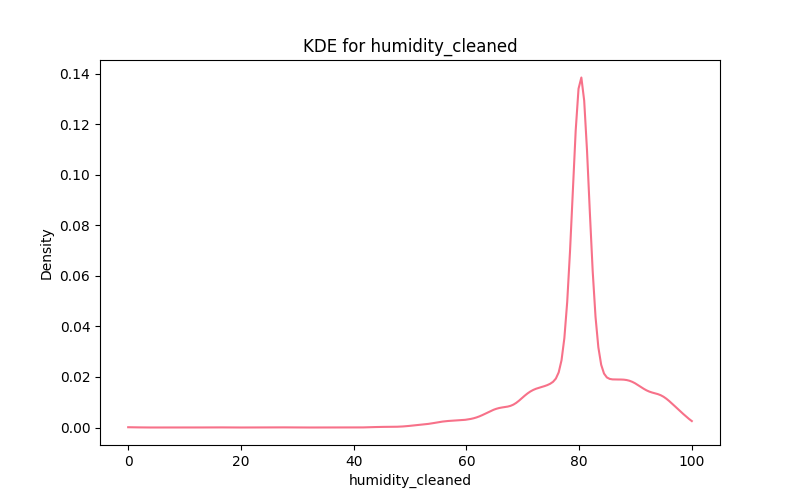

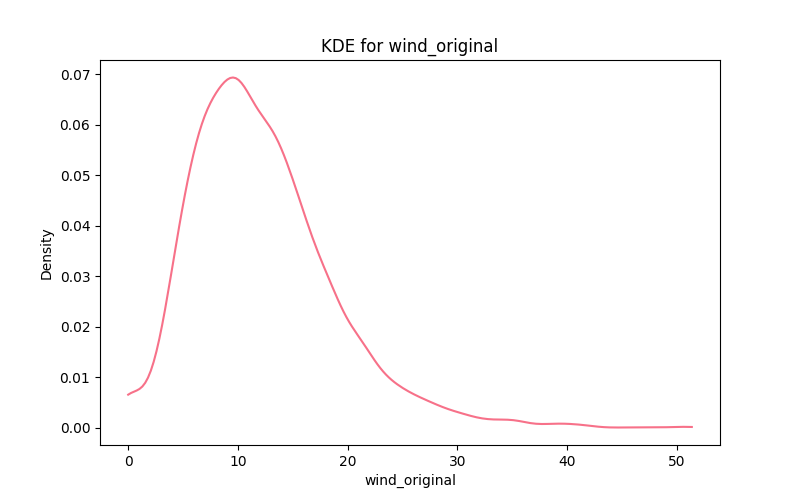

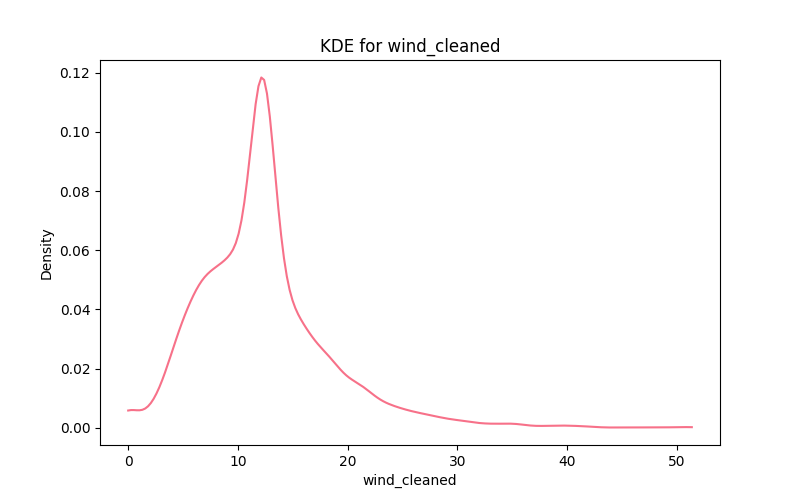

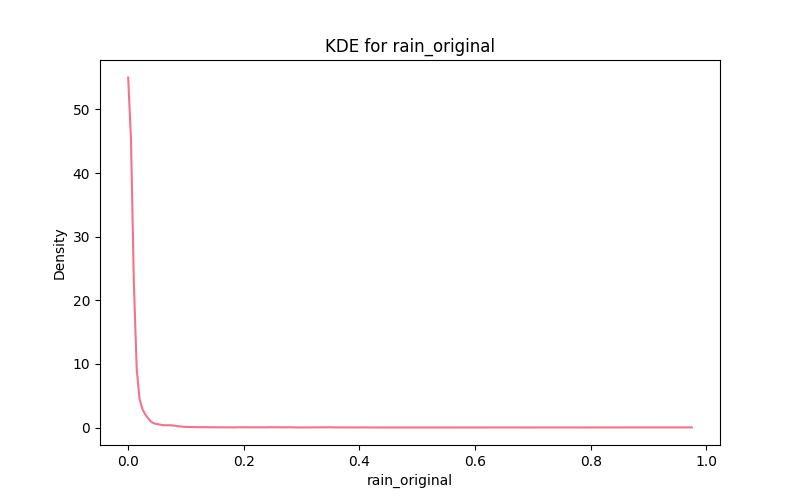

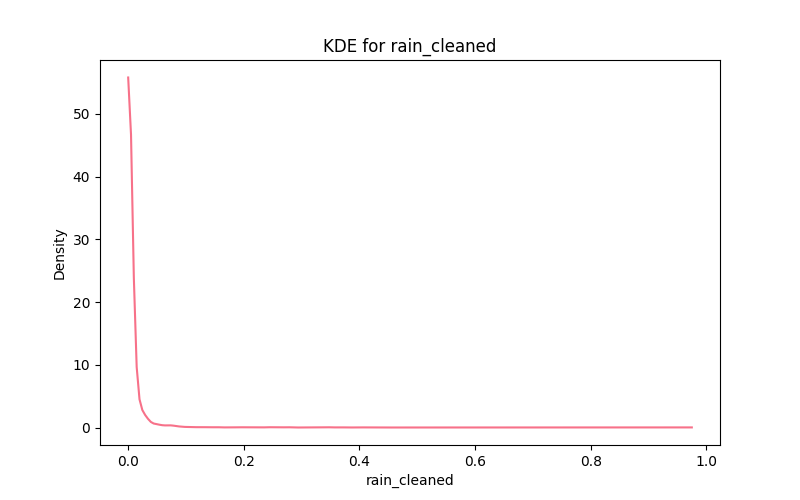

In [6]:
# Instantiate UncertaintyAgent
uncertainty_agent = UncertaintyAgent(output_dir='outputs/uncertainty')

# Run analysis comparing ingested vs cleaned distributions
uncertainty_result = uncertainty_agent.run_analysis(ingested_df, cleaned_df)

# Print prob_loss for each variable (Total Variation distance: 0 = identical, 1 = disjoint)
print("--- Probability Loss (cleaning impact) ---")
for var, res in uncertainty_result.items():
    pl = res.get('prob_loss')
    if pl is not None:
        bar = '█' * int(pl * 40)
        print(f"  {var:>22s}: {pl:.4f}  {bar}")

# Display KDE comparison plots for core meteorological variables
for var in ['temperature', 'humidity', 'wind', 'rain']:
    if var in uncertainty_result:
        res = uncertainty_result[var]
        if res.get('original_kde_plot') is not None:
            display(Image(res['original_kde_plot']))
        if res.get('cleaned_kde_plot') is not None:
            display(Image(res['cleaned_kde_plot']))

## Visualization

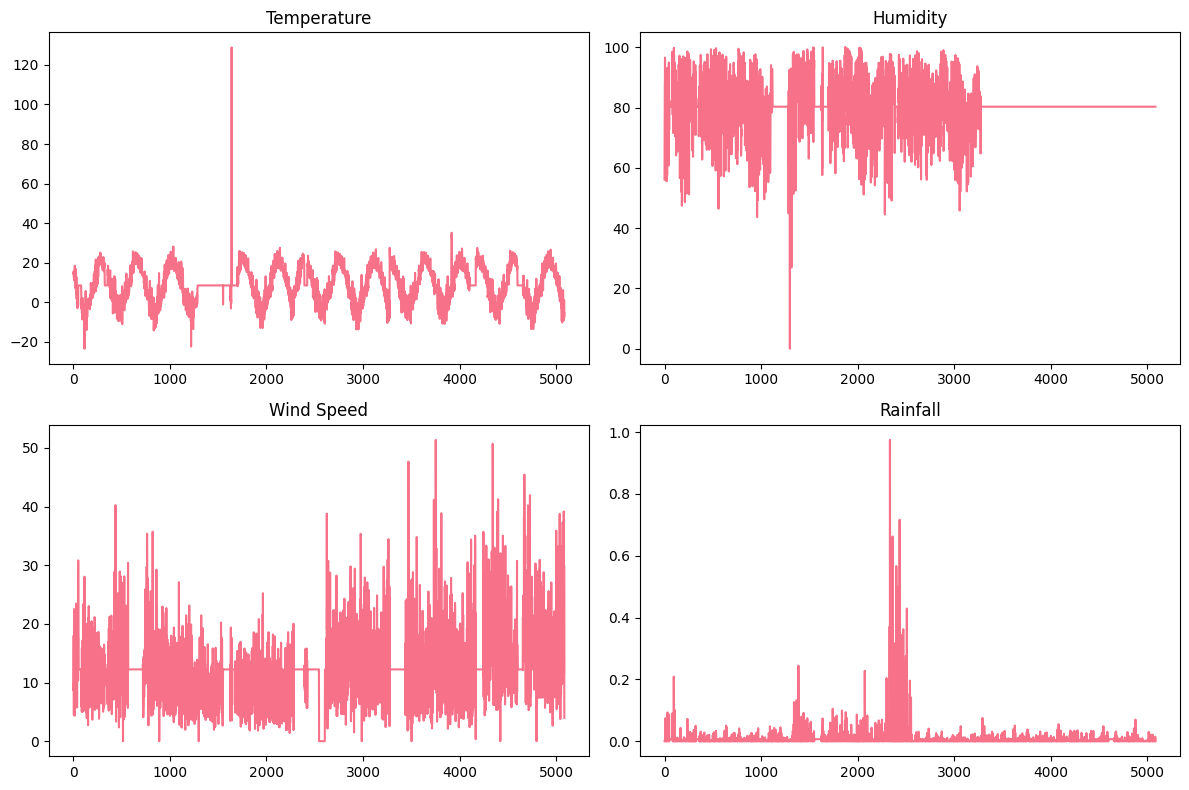

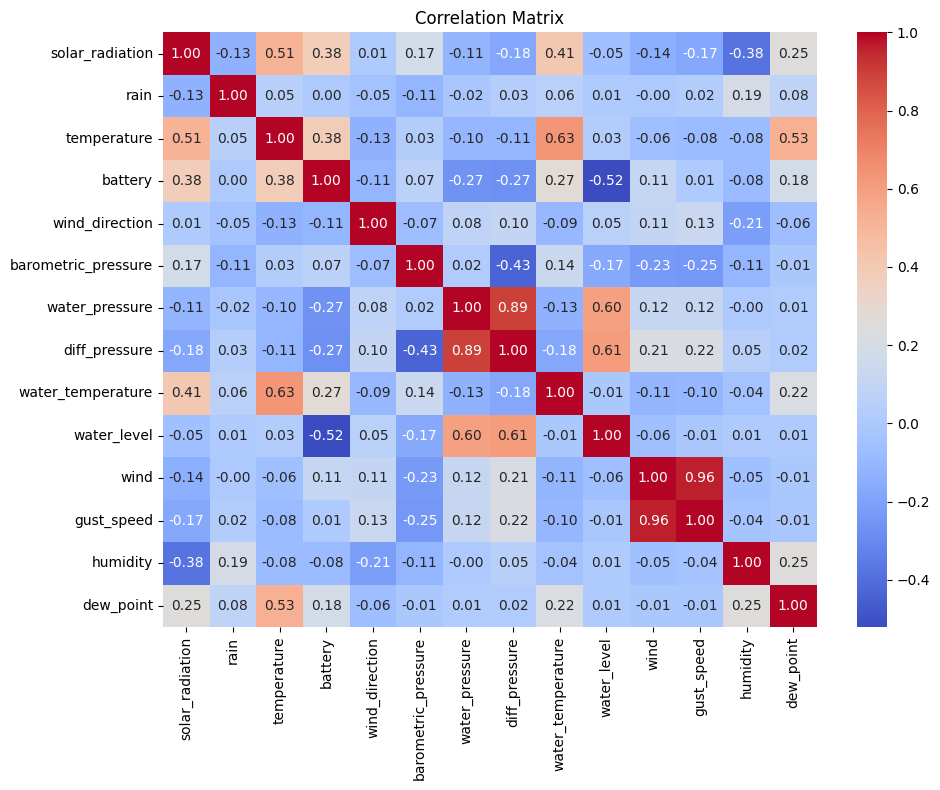

In [7]:
# Additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Temperature over time
if 'temperature' in cleaned_df.columns:
    cleaned_df['temperature'].plot(ax=axes[0, 0], title='Temperature')

# Humidity
if 'humidity' in cleaned_df.columns:
    cleaned_df['humidity'].plot(ax=axes[0, 1], title='Humidity')

# Wind
if 'wind' in cleaned_df.columns:
    cleaned_df['wind'].plot(ax=axes[1, 0], title='Wind Speed')

# Rain
if 'rain' in cleaned_df.columns:
    cleaned_df['rain'].plot(ax=axes[1, 1], title='Rainfall')

plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_df = cleaned_df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Summary & Recommendations

This section consolidates findings from every pipeline stage and translates them into actionable recommendations for PEINP microclimate monitoring.

In [8]:
# ── 1. DATA QUALITY ──────────────────────────────────────────
n_raw = len(ingested_df)
n_clean = len(cleaned_df)
cols_dropped = set(ingested_df.columns) - set(cleaned_df.columns)
cols_kept = list(cleaned_df.columns)
pct_rows_retained = n_clean / n_raw * 100 if n_raw else 0

print("=" * 60)
print("1. DATA QUALITY")
print("=" * 60)
print(f"   Raw rows (daily):     {n_raw:,}")
print(f"   Cleaned rows:         {n_clean:,}  ({pct_rows_retained:.1f}% retained)")
print(f"   Columns kept ({len(cols_kept)}):  {cols_kept}")
if cols_dropped:
    print(f"   Columns dropped:      {sorted(cols_dropped)}")
print()

# ── 2. REDUNDANCY (PCA & CLUSTERING) ────────────────────────
print("=" * 60)
print("2. REDUNDANCY ANALYSIS")
print("=" * 60)

if redundancy_result.get('pca') is not None:
    ev = redundancy_result['pca']['explained_variance']
    cumulative = np.cumsum(ev)
    n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
    print(f"   PCA components computed: {len(ev)}")
    print(f"   Variance explained:     {[f'{v:.2%}' for v in ev]}")
    print(f"   Components for >=90%:   {n_90}")
    if n_90 < len(cols_kept) - 1:
        print(f"   -> {len(cols_kept) - 1 - n_90} variable(s) may be redundant")
else:
    print("   PCA: not available")

if redundancy_result.get('clusters') is not None:
    cluster_counts = pd.Series(redundancy_result['clusters']).value_counts().sort_index()
    print(f"   K-Means clusters:       {dict(cluster_counts)}")
else:
    print("   Clustering: not available")
print()

# ── 3. FIRE WEATHER INDEX ───────────────────────────────────
print("=" * 60)
print("3. FWI VALIDATION")
print("=" * 60)

print(f"   Days computed:  {len(fwi_df):,}")
print(f"   FWI range:      {fwi_df['fwi'].min():.2f} - {fwi_df['fwi'].max():.2f}")
print(f"   FWI mean:       {fwi_df['fwi'].mean():.2f}")

status = "PASSED" if validation_report.get('all_passed') else "FAILED"
print(f"   Range check:    {status}")

# Flag elevated fire-weather days (FWI >= 10 is "High" in Canadian system)
high_days = (fwi_df['fwi'] >= 10).sum()
very_high_days = (fwi_df['fwi'] >= 20).sum()
print(f"   High FWI days (>=10):      {high_days}")
print(f"   Very-High FWI days (>=20): {very_high_days}")
print()

# ── 4. UNCERTAINTY (CLEANING IMPACT) ────────────────────────
print("=" * 60)
print("4. UNCERTAINTY - PROBABILITY LOSS FROM CLEANING")
print("=" * 60)

pl_values = {}
for var, res in uncertainty_result.items():
    pl = res.get('prob_loss')
    if pl is not None:
        pl_values[var] = pl

if pl_values:
    sorted_pl = sorted(pl_values.items(), key=lambda x: x[1], reverse=True)
    for var, pl in sorted_pl:
        flag = " << high impact" if pl > 0.10 else ""
        print(f"   {var:>22s}: {pl:.4f}{flag}")

    most_affected = sorted_pl[0]
    least_affected = sorted_pl[-1]
    print()
    print(f"   Most affected:   {most_affected[0]} (TV = {most_affected[1]:.4f})")
    print(f"   Least affected:  {least_affected[0]} (TV = {least_affected[1]:.4f})")
else:
    print("   No prob_loss values computed.")
print()

# ── 5. RECOMMENDATIONS ──────────────────────────────────────
print("=" * 60)
print("5. RECOMMENDATIONS")
print("=" * 60)

recs = []

# Redundancy recommendation
if redundancy_result.get('pca') is not None:
    ev = redundancy_result['pca']['explained_variance']
    cumulative = np.cumsum(ev)
    n_90 = int(np.searchsorted(cumulative, 0.90)) + 1
    total_numeric = len(cleaned_df.select_dtypes(include=['float64', 'int64']).columns)
    if n_90 < total_numeric:
        recs.append(
            f"PCA shows {n_90} components capture >=90% of variance from "
            f"{total_numeric} variables. Consider reviewing low-contribution "
            f"sensors for potential decommissioning or reduced sampling frequency."
        )

# FWI recommendation
if very_high_days > 0:
    recs.append(
        f"{very_high_days} day(s) with Very-High FWI (>=20) detected. "
        f"Cross-reference these dates with operational fire preparedness records."
    )

# Uncertainty recommendation
if pl_values:
    high_impact = [v for v, p in pl_values.items() if p > 0.10]
    if high_impact:
        recs.append(
            f"Variables with high cleaning impact (TV > 0.10): {high_impact}. "
            f"Investigate sensor calibration or data-logger reliability for these channels."
        )
    low_impact = [v for v, p in pl_values.items() if p < 0.01]
    if low_impact:
        recs.append(
            f"Variables with negligible cleaning impact (TV < 0.01): {low_impact}. "
            f"These sensors are producing high-quality data consistently."
        )

if not recs:
    recs.append("All checks passed with no actionable concerns.")

for i, rec in enumerate(recs, 1):
    print(f"   {i}. {rec}")

print()
print("=" * 60)
print("Pipeline complete. All outputs saved under outputs/ and data/.")
print("=" * 60)

1. DATA QUALITY
   Raw rows (daily):     5,086
   Cleaned rows:         5,086  (100.0% retained)
   Columns kept (16):  ['station', 'timestamp', 'solar_radiation', 'rain', 'temperature', 'battery', 'wind_direction', 'barometric_pressure', 'water_pressure', 'diff_pressure', 'water_temperature', 'water_level', 'wind', 'gust_speed', 'humidity', 'dew_point']
   Columns dropped:      ['accumulated_rain', 'gust_speed_ms', 'water_flow', 'wind_speed_ms']

2. REDUNDANCY ANALYSIS
   PCA components computed: 3
   Variance explained:     ['23.06%', '15.26%', '14.57%']
   Components for >=90%:   4
   -> 11 variable(s) may be redundant
   K-Means clusters:       {0: np.int64(351), 1: np.int64(2322), 2: np.int64(2413)}

3. FWI VALIDATION
   Days computed:  5,086
   FWI range:      0.68 - 55.79
   FWI mean:       13.06
   Range check:    PASSED
   High FWI days (>=10):      3750
   Very-High FWI days (>=20): 489

4. UNCERTAINTY - PROBABILITY LOSS FROM CLEANING
              water_level: 0.4790 << high